# CTD–model comparison (HAFRO vs Iceland2)

This notebook compares HAFRO CTD profiles in Hvalfjörður with the Iceland2_MARBL_2024 model solution.

- **Data loading**: Read CTD casts from `Hafro_cruises.xls` and convert to an `xarray.Dataset` with station (`HV`), depth, and time.
- **Grid/regridding**: Load the Iceland2 grid and ROMS history files, regrid temperature and salinity to fixed depth levels.
- **Profile comparison**: Extract model values at station locations and compare mean and variability of $T$ and $S$ vs depth.
- **Section plots**: Build along- and across-fjord mean sections for model and observations.
- **BGC diagnostics**: Extend the analysis to BGC fields (chlorophyll, oxygen, saturation) using paired HAFRO and model output.

Use this to evaluate how well the model reproduces observed hydrography and BGC structure over 2024.

# Comparison of the HAFRO CTD data with ROMS model output

This notebook loads the observed CTD data and model data. It converts observed data to xarray format, and regrids model data onto lat,lon,z coordinates. There are some options available to reduce the model data loaded in for the sake of available memory. It then makes various plots of stratification and seasonal evolution of salinity and temperature. We use the roms-tools regridder.

In [68]:
# Loading in modules

import subprocess
import os
import pandas as pd
import netCDF4
import numpy as np
import glob
import time
import matplotlib.pyplot as plt
import copy

import xarray as xr
from datetime import datetime, timedelta 
import dask
from scipy.interpolate import griddata
#from ocean_c_lab_tools import *
#from celluloid import Camera 
#import PyCO2SYS as csys
#import seawater as sw
from roms_regrid import *

### Setting parameters and paths

Here, all the parameters for model regridding, the paths for data storage, and the chosen length of model comparison are set, so that the remainder of the notebook needs minimal adjustment

In [69]:
obs_path='//anvil/projects/x-ees250129/x-uheede/C-Star-in-Hvalfjordur/data/staged/seanoe_hvalfjordur/2026-04-27/seanoe_110439/ctd_profiles_qc/ctd_profiles_qc.xlsx'
model_grid_path="/home/x-uheede/S/Iceland2_MARBL_2024_60m/P_INPUT/Iceland2_grid.nc"
# Grid parameters, only modify these if grid is made in MATLAB
vert_levels=60
theta_s_model=5
theta_b_model=2
hc_model=300
model_data_path="/home/x-uheede/R/Iceland_experiments/Iceland2_MARBL_2024_60m/Iceland2_MARBL_2024_his.2024??????????.nc"
model_data_path1="/home/x-uheede/R/Iceland_experiments/Iceland2_MARBL_2024_60m/Iceland2_MARBL_2024_his.2024??????????.nc"
model_data_bgc_path="/home/x-uheede/R/Iceland_experiments/Iceland2_MARBL_2024_60m/Iceland2_MARBL_2024_bgc.2024??????????.nc"

months_analysis=[1,2,3,4,5,6,7,8,9,10,11,12] # enter the months you want to analyze for the model·
# enter the dates you want to analyze for the observations
months_string_begin='01-04-2024'
months_string_end='30-11-2024'
target_depth_levels=[1,2,3,4,5,7,9,10,12,14,15,16,18,20,26,30,36,40,50,80] # Specify depth levels of interest
target_depth_levels_bgc=[1,3,5,8,10,15,20,30]
thinner=24*7 # specify the temporal frequency of data being read (i.e. no need to read in hourly data)
thinner_bgc=7

In [70]:
# Read in observed data
xls = pd.ExcelFile(obs_path)

combo = pd.read_excel(
    xls, 
    'CTD_data_Hvalfjordur2024_2025',
    decimal='.',
    header=25,
    skiprows=[26] 
)

# 1. Create the 'HV' column by removing 'HV' and converting to integer
# We use .str.replace with regex=False for a simple string swap
combo['HV'] = combo['Station_name'].str.replace('HV', '', regex=False).astype(int)

# 2. Create the 'time' column
combo['time'] = pd.to_datetime(combo[['Year_UTC', 'Month_UTC', 'Day_UTC']].rename(
    columns={'Year_UTC': 'year', 'Month_UTC': 'month', 'Day_UTC': 'day'}
))

# 3. Convert to xarray Dataset
obs = xr.Dataset.from_dataframe(combo)

# 4. Reformat using 'HV' as the station index
obs = obs.set_index(index=['HV', 'Depth', 'time'])
obs = obs.drop_duplicates('index')
obs = obs.unstack('index')

# 5. Renaming variables
obs = obs.rename(name_dict={
    'Depth': 'depth',
    'Latitude': 'lat',
    'Longitude': 'lon'
})

In [71]:
obs.time

<xarray.DataArray 'time' (time: 22)> Size: 176B
array(['2024-04-04T00:00:00.000000000', '2024-04-16T00:00:00.000000000',
       '2024-04-26T00:00:00.000000000', '2024-05-13T00:00:00.000000000',
       '2024-05-28T00:00:00.000000000', '2024-06-11T00:00:00.000000000',
       '2024-06-26T00:00:00.000000000', '2024-07-09T00:00:00.000000000',
       '2024-07-25T00:00:00.000000000', '2024-08-14T00:00:00.000000000',
       '2024-08-15T00:00:00.000000000', '2024-09-19T00:00:00.000000000',
       '2024-10-08T00:00:00.000000000', '2024-10-09T00:00:00.000000000',
       '2024-11-21T00:00:00.000000000', '2025-01-09T00:00:00.000000000',
       '2025-02-17T00:00:00.000000000', '2025-03-06T00:00:00.000000000',
       '2025-03-18T00:00:00.000000000', '2025-03-28T00:00:00.000000000',
       '2025-04-10T00:00:00.000000000', '2025-04-28T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 176B 2024-04-04 2024-04-16 ... 2025-04-28

In [72]:
# define location which calculations the average location of each station
def get_location(obs, hv_values):
    locations = []
    for hv in hv_values:
        lat = obs['lat'].sel(HV=hv).isel(depth=0).mean('time').squeeze().values
        lon = obs['lon'].sel(HV=hv).isel(depth=0).mean('time').squeeze().values + 360
        locations.append([lat, lon])
    return locations

# List of HV values
hv_values = range(1, 13)

# Get the locations
locations = get_location(obs, hv_values)

In [73]:
from roms_tools import Grid, ROMSOutput

In [74]:
grid = Grid.from_file(
    model_grid_path
)

In [75]:
##Only run this cell if grid is made in MATLAB
#grid.update_vertical_coordinate(N=vert_levels, theta_s=theta_s_model, theta_b=theta_b_model, hc=hc_model, verbose=False)

In [76]:
import xarray as xr
import numpy as np

# Load ROMS output using your pattern
roms_output = ROMSOutput(
    grid=grid,
    path=[
        model_data_path,
    ],
    use_dask=True,
)

ds = roms_output.regrid(var_names=["temp", "salt"],depth_levels=target_depth_levels)
ds = ds.sel(time=~ds.time.to_index().duplicated())
ds_sel = ds.sel(
    time=obs['time'],
    method="nearest"
)

# Extract month for each time entry
months = ds_sel.time.dt.month

# Dimensions we want
month_vals = months_analysis
types = ["mean", "std"]

# Create empty datasets for salt & temp
salt_data = []
temp_data = []

for m in month_vals:
    ds_m = ds_sel.sel(time=months == m)

    # Calculate and append mean & std
    salt_mean = ds_m["salt"].mean("time").load()
    salt_std  = ds_m["salt"].std("time").load()
    temp_mean = ds_m["temp"].mean("time").load()
    temp_std  = ds_m["temp"].std("time").load()

    salt_data.append(xr.concat([salt_mean, salt_std], dim="type"))
    temp_data.append(xr.concat([temp_mean, temp_std], dim="type"))

# Concatenate over month dimension
salt_all = xr.concat(salt_data, dim="month")
temp_all = xr.concat(temp_data, dim="month")

# Assign coordinates
salt_all = salt_all.assign_coords(type=types, month=month_vals)
temp_all = temp_all.assign_coords(type=types, month=month_vals)

# Build final dataset
ds_monthly = xr.Dataset(
    {
        "salt": salt_all,
        "temp": temp_all,
    }
)

print(ds_monthly)



<xarray.Dataset> Size: 1GB
Dimensions:  (lat: 481, lon: 721, depth: 20, type: 2, month: 12)
Coordinates:
  * lat      (lat) float32 2kB 63.0 63.0 63.01 63.01 ... 64.99 64.99 65.0 65.0
  * lon      (lon) float32 3kB 336.0 336.0 336.0 336.0 ... 339.0 339.0 339.0
  * depth    (depth) float32 80B 1.0 2.0 3.0 4.0 5.0 ... 36.0 40.0 50.0 80.0
  * type     (type) <U4 32B 'mean' 'std'
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    salt     (month, type, lat, lon, depth) float32 666MB nan nan ... nan nan
    temp     (month, type, lat, lon, depth) float32 666MB nan nan ... nan nan


In [77]:
ds_sel.time

<xarray.DataArray 'time' (time: 22)> Size: 176B
array(['2024-04-04T00:00:00.000000000', '2024-04-16T00:00:00.000000000',
       '2024-04-26T00:00:00.000000000', '2024-05-13T00:00:00.000000000',
       '2024-05-28T00:00:00.000000000', '2024-06-11T00:00:00.000000000',
       '2024-06-26T00:00:00.000000000', '2024-07-09T00:00:00.000000000',
       '2024-07-25T00:00:00.000000000', '2024-08-14T00:00:00.000000000',
       '2024-08-15T00:00:00.000000000', '2024-09-19T00:00:00.000000000',
       '2024-10-08T00:00:00.000000000', '2024-10-09T00:00:00.000000000',
       '2024-11-21T00:00:00.000000000', '2024-11-29T23:00:00.000000000',
       '2024-11-29T23:00:00.000000000', '2024-11-29T23:00:00.000000000',
       '2024-11-29T23:00:00.000000000', '2024-11-29T23:00:00.000000000',
       '2024-11-29T23:00:00.000000000', '2024-11-29T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 176B 2024-04-04 ... 2024-11-29T23:00:00
Attributes:
    long_name:  Time

In [78]:
t=ds_monthly['temp']
s=ds_monthly['salt']



In [79]:
# Assuming locations is a list of lat/lon pairs
t_values = []
s_values = []
# Loop over the first 10 locations and store each selection in t_values
for i in range(12):
    lat, lon = locations[i]
    
    # Select the 't' values at the nearest lat/lon
    t_selected = t.sel(lat=lat, method='nearest').sel(lon=lon, method='nearest')
    s_selected = s.sel(lat=lat, method='nearest').sel(lon=lon, method='nearest')
    
    # Store the result in the listx
    t_values.append(t_selected)
    s_values.append(s_selected)

# Combine the selections into an xarray Dataset or DataArray
t_values_combined = xr.concat(t_values, dim='location')
s_values_combined = xr.concat(s_values, dim='location')

# Combine the selections into an xarray Dataset or DataArray
t_values_combined = xr.concat(t_values, dim='location')
s_values_combined = xr.concat(s_values, dim='location')

# Assign a location coordinate for clarity (optional)
t_values_combined = t_values_combined.assign_coords(location=('location', range(1, 13)))
s_values_combined = s_values_combined.assign_coords(location=('location', range(1, 13)))
t_values_combined['depth']=t_values_combined.depth*(-1)
s_values_combined['depth']=s_values_combined.depth*(-1)
# Now you have t_values as an xarray object (Dataset or DataArray)
#print(t_values_combined)


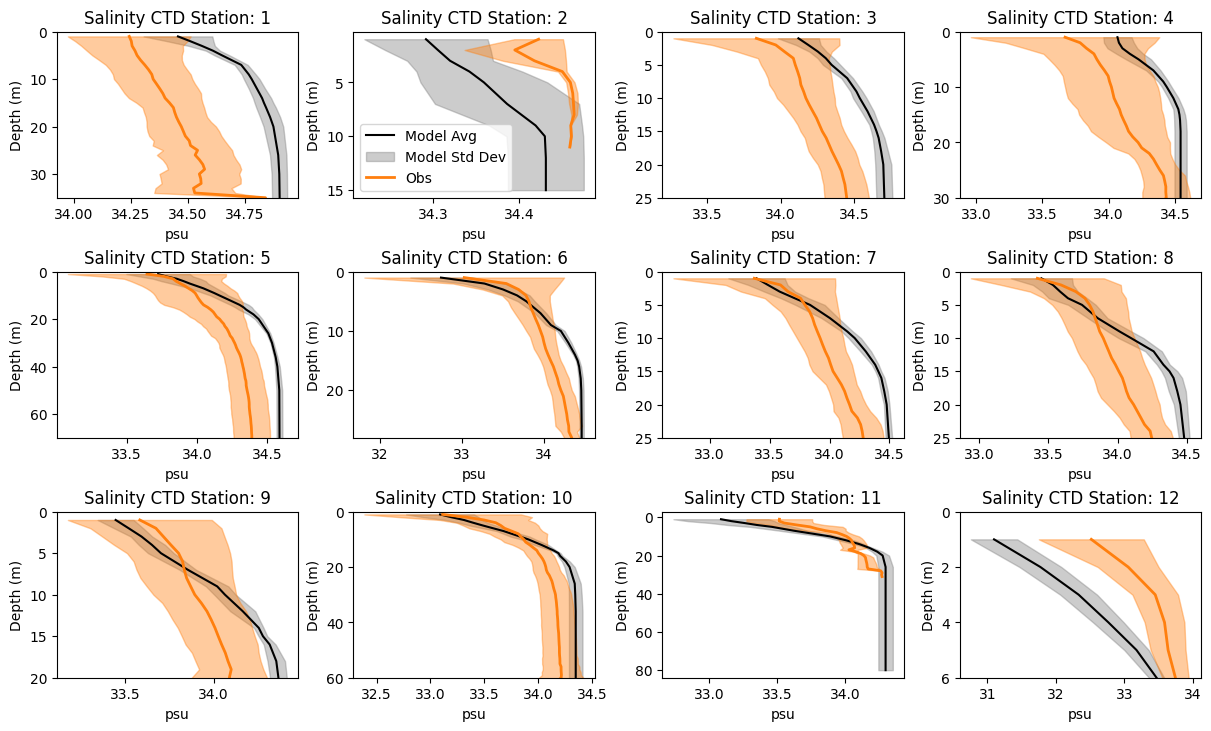

In [80]:
import matplotlib.pyplot as plt

# --- PRE-PROCESSING: Apply QC Flag ---
# Filter salinity to only include values where the flag is 2 (Good Data)
obs_clean = obs.copy()
obs_clean['Salinity_CTD'] = obs_clean['Salinity_CTD'].where(obs_clean['Salinity_CTD_flag'] == 2)

# Set up the subplots
fig, axarr = plt.subplots(nrows=3, ncols=4, figsize=(12, 6*1.2), constrained_layout=True)
ax = axarr.flatten()
palette = plt.get_cmap('tab20')

# Loop through 12 locations
for i in range(12):
    loc = i + 1 

    # --- MODEL DATA ---
    model_mean = s_values_combined.isel(type=0).isel(month=slice(3,9)).mean('month').sel(location=loc)
    model_std = s_values_combined.isel(type=1).isel(month=slice(3,9)).mean('month').sel(location=loc)

    ax[i].plot(model_mean, s_values_combined.depth*(-1), label='Model Avg', color='black')
    ax[i].fill_betweenx(s_values_combined.depth*(-1), model_mean - model_std, model_mean + model_std, 
                         color='grey', alpha=0.4, label='Model Std Dev')

    # --- OBSERVED DATA (Using obs_clean) ---
    # Select the specific station and time range
    obs_loc = obs_clean.sel(HV=loc).sel(time=slice(months_string_begin, months_string_end))
    
    # Calculate Mean and Std Dev
    obs_mean = obs_loc['Salinity_CTD'].mean('time')
    obs_std = obs_loc['Salinity_CTD'].std('time')
    
    # Plot observed average
    ax[i].plot(obs_mean, obs_loc.depth, label='Obs', color=palette(2), linewidth=2)

    # Plot shaded region for observed standard deviation
    ax[i].fill_betweenx(obs_loc.depth, 
                        obs_mean - obs_std, 
                        obs_mean + obs_std, 
                        color=palette(2), alpha=0.4)

    # --- FORMATTING ---
    # Set depth limits for specific subplots
    depth_limits = {0: 35, 2: 25, 3: 30, 4: 70, 5: 28, 6: 25, 7: 25, 8: 20, 9: 60, 11: 6}
    if i in depth_limits:
        ax[i].set_ylim(depth_limits[i], 0) # Note: Inverting via ylim directly
    else:
        ax[i].invert_yaxis()

    ax[i].set_title(f'Salinity CTD Station: {obs_clean.HV.sel(HV=loc).values}')
    ax[i].set_xlabel('psu')
    ax[i].set_ylabel('Depth (m)')

    if i == 1:
        ax[i].legend()

# Display the plot
plt.show()

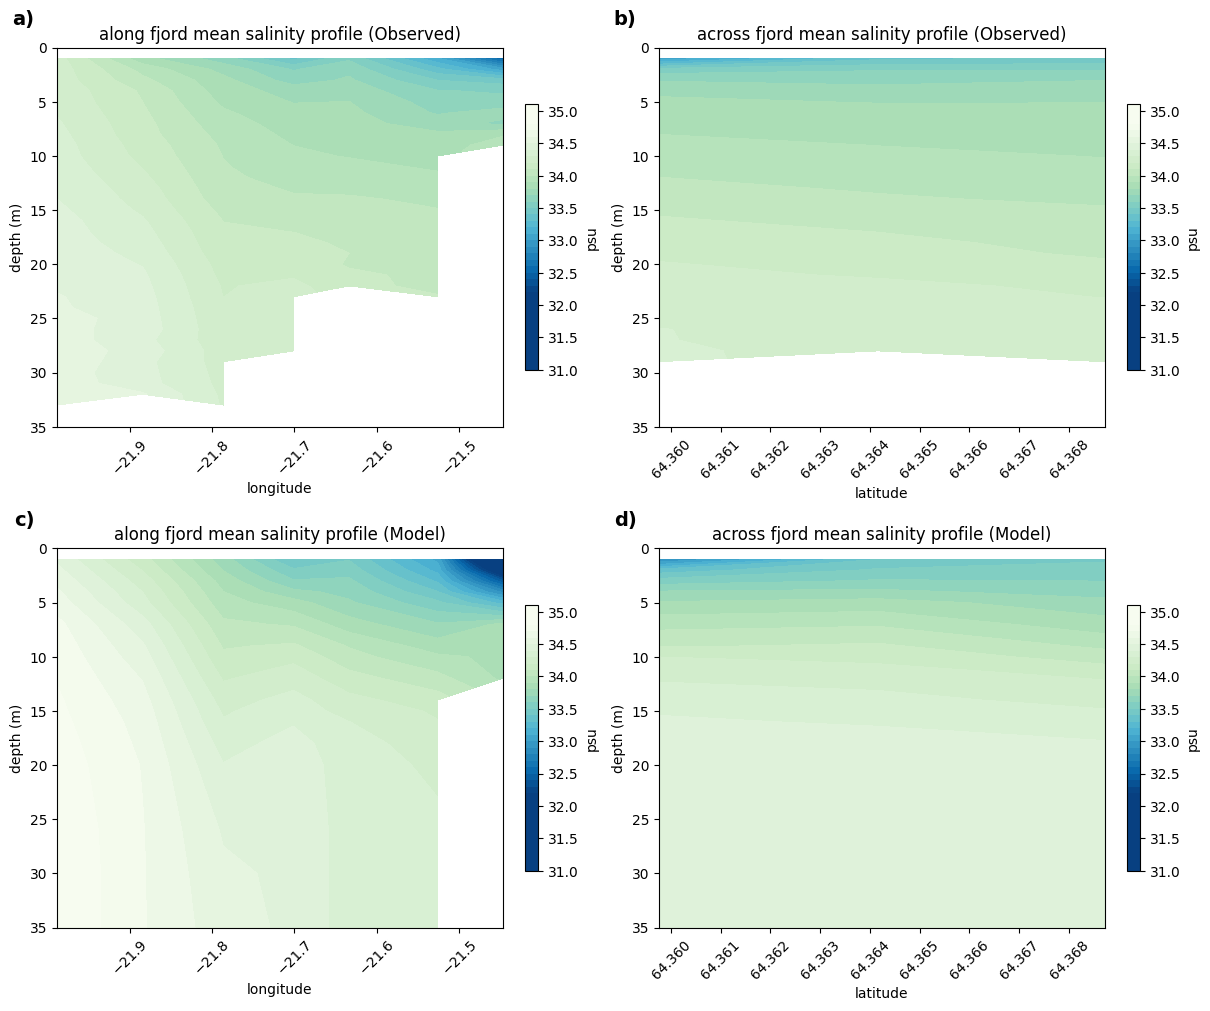

In [81]:
import matplotlib.pyplot as plt
import numpy as np

obs_clean = obs.copy()
obs_clean['Salinity_CTD'] = obs_clean['Salinity_CTD'].where(obs_clean['Salinity_CTD_flag'] == 2)

# --- Setup ---
loc = np.array(locations)
levels_psu = np.arange(31, 35.1, 0.1)

# --- Prepare Data ---
# Observed
data_psu1_obs = obs_clean['Salinity_CTD'].sel(time=slice(months_string_begin, months_string_end)).sel(HV=[1,3,5,7,9,10,12]).mean('time')
data_psu2_obs = obs_clean['Salinity_CTD'].sel(time=slice(months_string_begin, months_string_end)).sel(HV=[6,7,8]).mean('time')

# Model
data_psu1_mod = s_values_combined.isel(type=0).isel(month=slice(3,10)).mean('month').sel(location=[1,3,5,7,9,10,12])
data_psu2_mod = s_values_combined.isel(type=0).isel(month=slice(3,10)).mean('month').sel(location=[6,7,8])

# --- Plotting ---
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 10), constrained_layout=True)
ax = ax.flatten()

# Define plot parameters for iteration to keep code clean
plot_data = [
    (loc[[1-1,3-1,5-1,7-1,9-1,10-1,12-1], 1]-360, data_psu1_obs, 'along fjord mean salinity profile (Observed)', 'longitude'),
    (loc[[6-1,7-1,8-1], 0], data_psu2_obs, 'across fjord mean salinity profile (Observed)', 'latitude'),
    (loc[[1-1,3-1,5-1,7-1,9-1,10-1,12-1], 1]-360, data_psu1_mod, 'along fjord mean salinity profile (Model)', 'longitude'),
    (loc[[6-1,7-1,8-1], 0], data_psu2_mod, 'across fjord mean salinity profile (Model)', 'latitude')
]

labels = ['a)', 'b)', 'c)', 'd)']
cmap='GnBu_r'
for i, (x_coords, data, title, xlabel) in enumerate(plot_data):
    # Handle depth difference between Obs and Model
    depth = data.depth if i < 2 else data.depth * (-1)
    
    # Plot contour
    cf = ax[i].contourf(x_coords, depth, data.transpose(), levels_psu,cmap=cmap, vmin=32.2, vmax= 34.8)
    
    # Formatting
    ax[i].set_title(title)
    ax[i].set_xlabel(xlabel)
    ax[i].set_ylabel('depth (m)')
    ax[i].set_ylim(0, 35)
    ax[i].invert_yaxis()


    # Rotate x-axis labels
    ax[i].tick_params(axis='x', labelrotation=45)   
    # Add Colorbar
    plt.colorbar(cf, ax=ax[i], orientation='vertical', label='psu', shrink=0.7)
    
    # Add Figure Marker (a, b, c, d)
    # transform=ax[i].transAxes uses a 0 to 1 coordinate system for the subplot
    ax[i].text(-0.05, 1.05, labels[i], transform=ax[i].transAxes, 
               fontsize=14, fontweight='bold', va='bottom', ha='right')

plt.show()

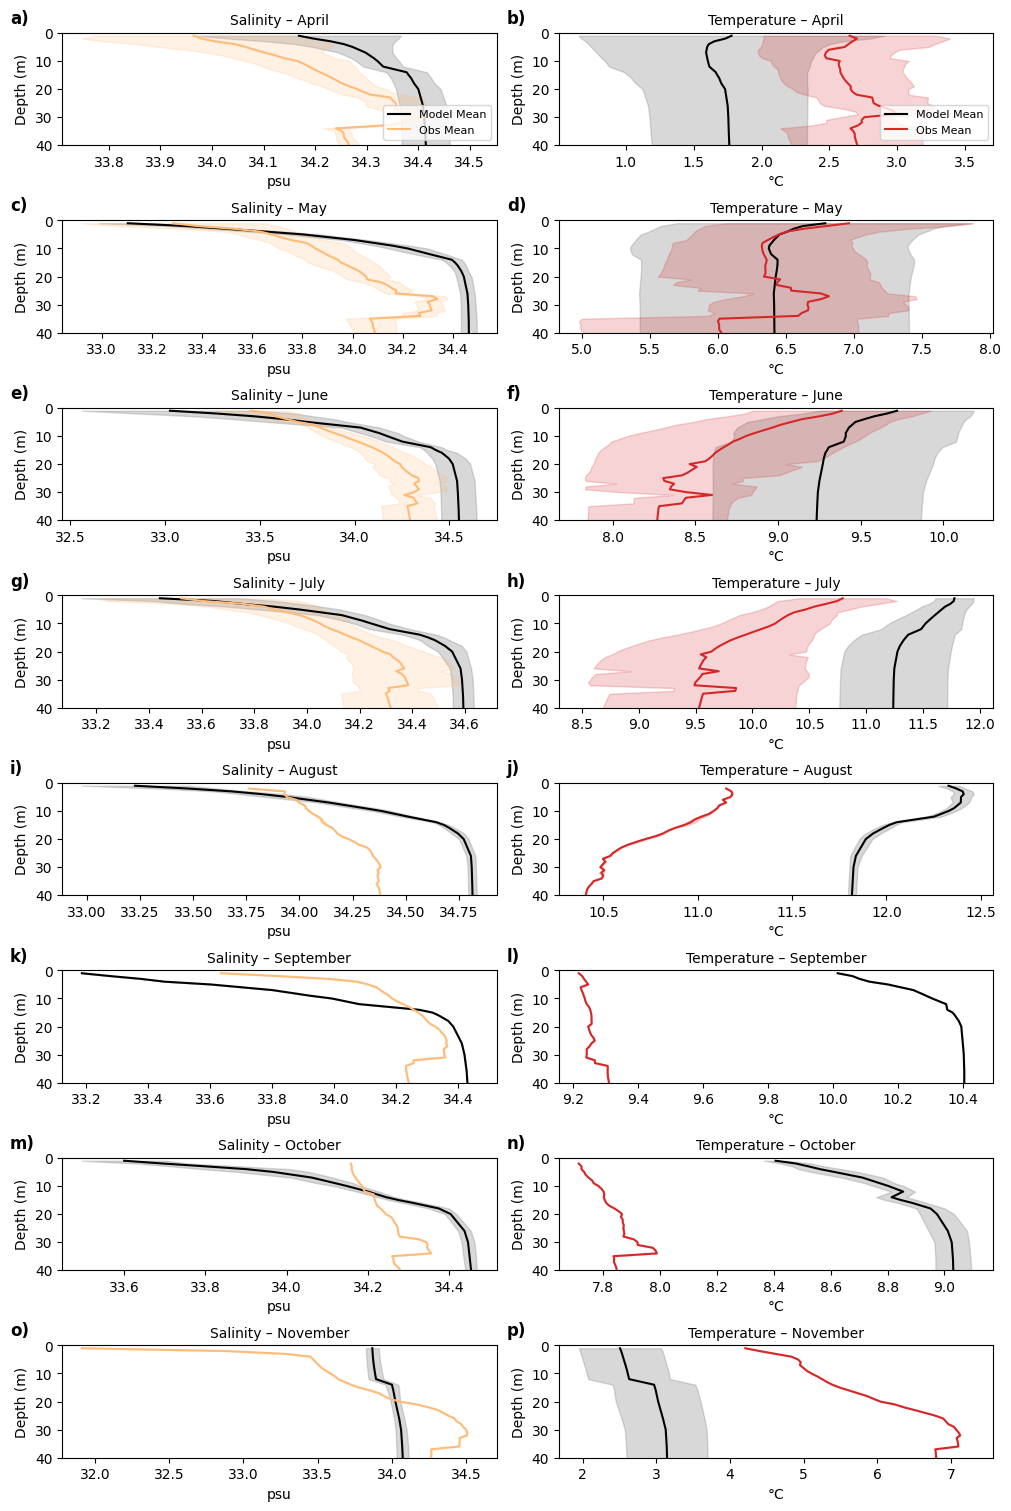

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import string

obs_clean = obs.copy()
obs_clean['Salinity_CTD'] = obs_clean['Salinity_CTD'].where(obs_clean['Salinity_CTD_flag'] == 2)
obs_clean['Temperature_CTD'] = obs_clean['Temperature_CTD'].where(obs_clean['TEMP_flag'] == 2)

# --- CONFIG ---
month_names = ["April", "May", "June", "July", "August","September","October","November"]
n_months = 8
palette = plt.get_cmap("tab20")
locations_idx = [1, 3, 4, 5, 6, 7, 8, 9, 10, 12]

# --- PREPARE DATA ---
# Model (Salinity & Temperature)
mod_s_mean = s_values_combined.isel(type=0).isel(month=slice(3,11)).sel(location=locations_idx).mean(dim="location")
mod_s_std  = s_values_combined.isel(type=1).isel(month=slice(3,11)).sel(location=locations_idx).mean(dim="location")

mod_t_mean = t_values_combined.isel(type=0).isel(month=slice(3,11)).sel(location=locations_idx).mean(dim="location")
mod_t_std  = t_values_combined.isel(type=1).isel(month=slice(3,11)).sel(location=locations_idx).mean(dim="location")

# Observations Lists
obs_s_mean_list, obs_s_std_list = [], []
obs_t_mean_list, obs_t_std_list = [], []

for m in range(n_months):
    month_str = f"2024-{m+3:02d}"
    # Use generic slice to capture the whole month
    obs_sel = obs_clean.sel(time=slice(f'2024-{m+4:02d}-01', f'2024-{m+4:02d}-30'))
    
    # Salinity Processing
    s_mean = obs_sel['Salinity_CTD'].mean(dim="time").sel(HV=locations_idx).mean(dim="HV")
    s_std  = obs_sel['Salinity_CTD'].std(dim="time").sel(HV=locations_idx).mean(dim="HV")
    obs_s_mean_list.append(s_mean)
    obs_s_std_list.append(s_std)
    
    # Temperature Processing
    t_mean = obs_sel["Temperature_CTD"].mean(dim="time").sel(HV=locations_idx).mean(dim="HV")
    t_std  = obs_sel["Temperature_CTD"].std(dim="time").sel(HV=locations_idx).mean(dim="HV")
    obs_t_mean_list.append(t_mean)
    obs_t_std_list.append(t_std)

# --- SET UP FIGURE (5 rows x 2 columns) ---
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(10, 15), constrained_layout=True)

alphabet = list(string.ascii_lowercase)

for m in range(n_months):
    for col in range(2):
        ax = axes[m, col]
        idx = m * 2 + col  # For a), b), c)... indexing
        
        if col == 0: # SALINITY COLUMN
            mod_m, mod_s = mod_s_mean.isel(month=m), mod_s_std.isel(month=m)
            obs_m, obs_s = obs_s_mean_list[m], obs_s_std_list[m]
            units, title_var = "psu", "Salinity"
            color_obs = palette(3) # Blue-ish
        else: # TEMPERATURE COLUMN
            mod_m, mod_s = mod_t_mean.isel(month=m), mod_t_std.isel(month=m)
            obs_m, obs_s = obs_t_mean_list[m], obs_t_std_list[m]
            units, title_var = "°C", "Temperature"
            color_obs = palette(6) # Red-ish

        # Plot Model
        ax.plot(mod_m, s_values_combined.depth*(-1), color='black', label="Model Mean", lw=1.5)
        ax.fill_betweenx(s_values_combined.depth*(-1), mod_m - mod_s, mod_m + mod_s, color="grey", alpha=0.3)

        # Plot Observations
        ax.plot(obs_m, obs.depth, color=color_obs, label="Obs Mean", lw=1.5)
        ax.fill_betweenx(obs.depth, obs_m - obs_s, obs_m + obs_s, color=color_obs, alpha=0.2)

        # Formatting
        ax.set_title(f"{title_var} – {month_names[m]}", fontsize=10)
        ax.set_xlabel(units)
        ax.set_ylabel("Depth (m)")
        ax.set_ylim(0, 40)
        ax.invert_yaxis()
        
        # Add Figure Marker (a, b, c...)
        ax.text(-0.12, 1.05, f"{alphabet[idx]})", transform=ax.transAxes, 
                fontsize=12, fontweight='bold', va='bottom')

        # Legend only on the first row
        if m == 0:
            ax.legend(fontsize=8, loc='lower right')

plt.show()

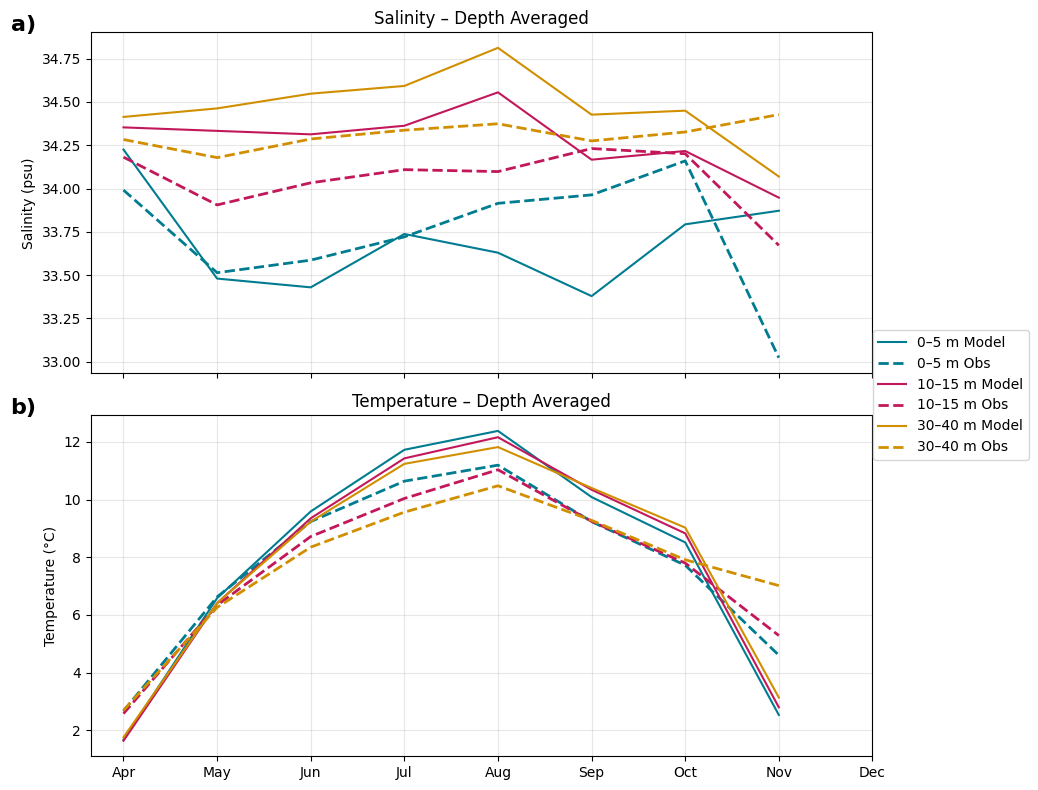

In [83]:
# Depth bins
depth_bins = {
    "0–5 m": (0, 5),
    "10–15 m": (10, 15),
    "30–40 m": (30, 40)
}

locations_idx = [1, 3, 4, 5, 6, 7, 8, 9, 10, 12]

# Select model mean (type=0) and desired months
mod_s = s_values_combined.isel(type=0).isel(month=slice(3,12)).sel(location=locations_idx).mean("location")
mod_t = t_values_combined.isel(type=0).isel(month=slice(3,12)).sel(location=locations_idx).mean("location")


months = np.arange(mod_s.month.size)

model_sal = {}
model_temp = {}

for label, (zmin, zmax) in depth_bins.items():
    model_sal[label] = mod_s.sel(depth=slice(zmin*(-1), zmax*(-1))).mean("depth")
    model_temp[label] = mod_t.sel(depth=slice(zmin*(-1), zmax*(-1))).mean("depth")


obs_sal = {}
obs_temp = {}

for label, (zmin, zmax) in depth_bins.items():
    sal_list = []
    temp_list = []

    for m in range(9):
        obs_sel = obs.sel(
            time=slice(f'2024-{m+4:02d}-01', f'2024-{m+4:02d}-30')
        ).sel(HV=locations_idx)

        sal_mean = (
            obs_sel["Salinity_CTD"].where(obs_sel['Salinity_CTD_flag'] == 2)
            .sel(depth=slice(zmin, zmax))
            .mean(("depth","time","HV"))
        )

        temp_mean = (
            obs_sel["Temperature_CTD"].where(obs_sel['TEMP_flag'] == 2)
            .sel(depth=slice(zmin, zmax))
            .mean(("depth","time","HV"))
        )

        sal_list.append(sal_mean)
        temp_list.append(temp_mean)

    obs_sal[label] = np.array(sal_list)
    obs_temp[label] = np.array(temp_list)

import matplotlib.pyplot as plt
import numpy as np

# Color map for depth bins
colors = {
    "0–5 m": "#007C91",   # deep teal
    "10–15 m": "#C2185B", # strong magenta
    "30–40 m": "#D18F00"  # warm golden
}

fig, axes = plt.subplots(2, 1, figsize=(9,8), sharex=True)

# =====================
# SALINITY
# =====================
ax = axes[0]

for label in depth_bins.keys():

    color = colors[label]

    # --- Model ---
    model_vals = np.array(model_sal[label])
    valid_model = ~np.isnan(model_vals)

    ax.plot(months[valid_model],
            model_vals[valid_model],
            color=color,
            linestyle="-",
            label=f"{label} Model")

    # --- Observations ---
    obs_vals = np.array(obs_sal[label])
    valid_obs = ~np.isnan(obs_vals)

    ax.plot(months[valid_obs],
            obs_vals[valid_obs],
            color=color,
            linestyle="--",
            linewidth=2,
            label=f"{label} Obs")

ax.set_ylabel("Salinity (psu)")
ax.set_title("Salinity – Depth Averaged")
ax.grid(alpha=0.3)
ax.text(-0.07, 1.05, 'a)', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# =====================
# TEMPERATURE
# =====================
ax = axes[1]

for label in depth_bins.keys():

    color = colors[label]

    # --- Model ---
    model_vals = np.array(model_temp[label])
    valid_model = ~np.isnan(model_vals)

    ax.plot(months[valid_model],
            model_vals[valid_model],
            color=color,
            linestyle="-",
            label=f"{label} Model")

    # --- Observations ---
    obs_vals = np.array(obs_temp[label])
    valid_obs = ~np.isnan(obs_vals)

    ax.plot(months[valid_obs],
            obs_vals[valid_obs],
            color=color,
            linestyle="--",
            linewidth=2,
            label=f"{label} Obs")

ax.set_ylabel("Temperature (°C)")
ax.set_title("Temperature – Depth Averaged")
ax.grid(alpha=0.3)

# Add Subplot Label a)


# Add Subplot Label b)
axes[1].text(-0.07, 1.05, 'b)', transform=ax.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# =====================
# Shared X-axis
# =====================
axes[1].set_xticks(months)
axes[1].set_xticklabels(["Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])

# =====================
# Single Combined Legend
# =====================
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right",bbox_to_anchor=(1.15, 0.5))

plt.tight_layout()
plt.show()



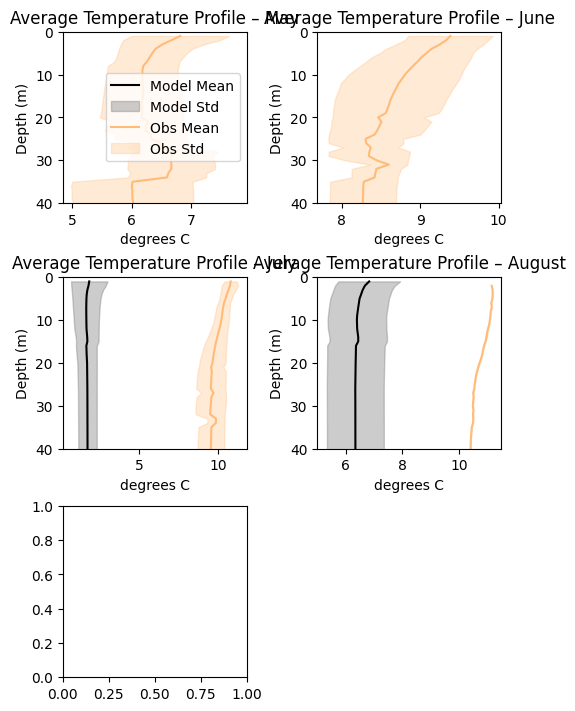

In [84]:
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIG ---
month_names = ["May", "June", "July", "August", "September"]
n_months = 4# May–Sep
palette = plt.get_cmap("tab20")

# --- TAKE MEAN OVER ALL 12 STATIONS ---
model_mean = t_values_combined.isel(type=0).mean(dim="location")
model_std  = t_values_combined.isel(type=1).mean(dim="location")

# --- OBSERVATIONS: MEAN + STD ACROSS STATIONS ---
obs_monthly_mean = []
obs_monthly_std = []

for m in range(n_months):
    month_str = f"2024-{m+4:02d}"   # 05–09
    obs_sel = obs["Temperature_CTD"].sel(
        time=slice('2024-0'+str(m+5)+'-01','2024-0'+str(m+5)+'-30')
    )

    # mean over stations, then mean over time
    obs_mean_m = obs_sel.mean(dim="time").mean(dim="HV")
    obs_std_m  = obs_sel.std(dim="time").mean(dim="HV")

    obs_monthly_mean.append(obs_mean_m)
    obs_monthly_std.append(obs_std_m)

# --- SET UP FIGURE ---
fig, axarr = plt.subplots(
    nrows=3, ncols=2, figsize=(5, 7), constrained_layout=True
)
ax = axarr.flatten()

for m in range(n_months):

    # MODEL DATA FOR MONTH m
    model_mean_m = model_mean.isel(month=m+1)
    model_std_m  = model_std.isel(month=m+1)

    # OBS DATA FOR MONTH m
    obs_mean_m = obs_monthly_mean[m]
    obs_std_m  = obs_monthly_std[m]

    # --- PLOTTING ---
    ax[m].plot(model_mean_m, s_values_combined.depth*(-1), color='black', label="Model Mean")
    ax[m].fill_betweenx(
        s_values_combined.depth*(-1),
        model_mean_m - model_std_m,
        model_mean_m + model_std_m,
        color="grey", alpha=0.4, label="Model Std"
    )

    ax[m].plot(obs_mean_m, obs.sel(HV=1).depth, color=palette(3), label="Obs Mean")
    ax[m].fill_betweenx(
        obs.sel(HV=1).depth,
        obs_mean_m - obs_std_m,
        obs_mean_m + obs_std_m,
        color=palette(3), alpha=0.3, label="Obs Std"
    )

    # TITLE + LABELS
    ax[m].set_title(f"Average Temperature Profile – {month_names[m]}")
    ax[m].set_xlabel("degrees C")
    ax[m].set_ylabel("Depth (m)")
    ax[m].set_ylim(0,40)
    # invert depth
    ax[m].invert_yaxis()

    # legend on first panel
    if m == 0:
        ax[m].legend()

# Remove empty subplot (6th)
fig.delaxes(ax[5])

plt.show()


In [85]:
import xarray as xr
import numpy as np

# Load ROMS output using your pattern
roms_output = ROMSOutput(
    grid=grid,
    path=[
        model_data_path,
    ],
    use_dask=True,
)

ds = roms_output.regrid(var_names=["temp", "salt"],depth_levels=[5])


In [86]:
t=ds['temp'].thin({'time': 24}).load()
s=ds['salt'].thin({'time': 24}).load()

In [87]:
# Define file paths and station names
stations = ["HVIN_1", "HVNA_1", "HVNV_1", "HVSA_1", "HVSV_1"]
file_paths = {name: f"/global/cfs/cdirs/m4632/uheede/Hafro_obsdata/{name}new.nc" for name in stations}
# Define file paths and station names
stations = ["HVIN_1", "HVNA_1", "HVNV_1", "HVSA_1", "HVSV_1"]
file_paths = {name: f"/home/x-uheede/R/HAFRO/{name}_TS.nc" for name in stations}

# Dictionary to store datasets
datasets = {}

for name, path in file_paths.items():
    ds = xr.open_dataset(path)
    
    # Store dataset with adjusted longitude
    datasets[name] = ds.assign_coords(lon=ds['lon'].load() + 360)

subtract = 739674 - 9189  # Computed constant
reference_date = pd.to_datetime("2000-01-01")  # Reference date

# Apply transformation to all datasets
for name, ds in datasets.items():
    datetime_series = reference_date + pd.to_timedelta((ds['time'].values - subtract), unit='D')
    datasets[name] = ds.assign_coords(time_dim=datetime_series)  # Update the time coordinate

ds_list = []

for name, ds in datasets.items():
    # Add station as a new dimension
    ds_expanded = ds.expand_dims(station=[name])
    ds_list.append(ds_expanded)
    
combined = xr.concat(ds_list, dim="station")
mean_ts = combined.mean(dim="station", skipna=True)

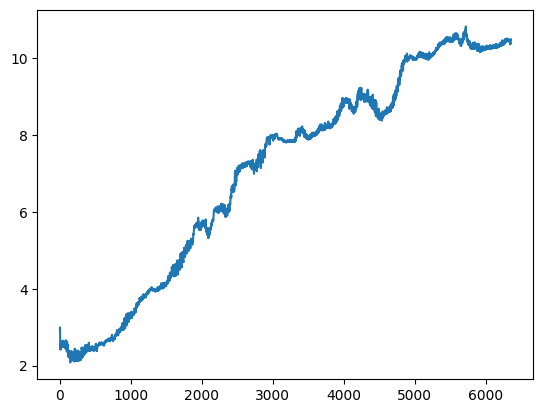

In [88]:
plt.plot(mean_ts['temperature'])

In [89]:
# Assuming locations is a list of lat/lon pairs
t_values = []
s_values = []
# Loop over the first 10 locations and store each selection in t_values
for i in range(12):
    lat, lon = locations[i]
    
    # Select the 't' values at the nearest lat/lon
    t_selected = t.sel(lat=lat, method='nearest').sel(lon=lon, method='nearest')
    s_selected = s.sel(lat=lat, method='nearest').sel(lon=lon, method='nearest')
    
    # Store the result in the listx
    t_values.append(t_selected)
    s_values.append(s_selected)

# Combine the selections into an xarray Dataset or DataArray
t_values_combined = xr.concat(t_values, dim='location')
s_values_combined = xr.concat(s_values, dim='location')

# Assign a location coordinate for clarity (optional)
t_values_combined = t_values_combined.assign_coords(location=('location', range(1, 13)))
s_values_combined = s_values_combined.assign_coords(location=('location', range(1, 13)))
#t_values_combined['depth']=t_values_combined.depth*(-1)
#s_values_combined['depth']=s_values_combined.depth*(-1)
# Now you have t_values as an xarray object (Dataset or DataArray)
#print(t_values_combined)


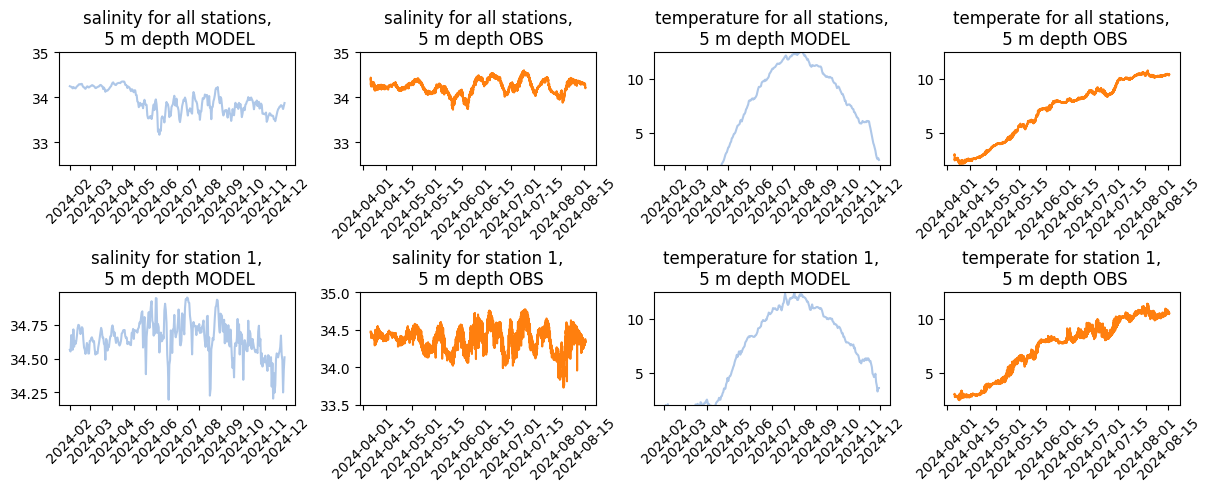

In [90]:
import matplotlib.pyplot as plt

# Set up the subplots
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(12, 4*1.2), constrained_layout=True)
ax = axarr.flatten()  # Flatten to make indexing easier
palette = plt.get_cmap('tab20')

# Plot observed salinity for May 2024
ax[1].plot(mean_ts['salinity'].time_dim.sel(time_dim=slice('04-01-2024', '09-01-2024')),
           mean_ts['salinity'].sel(time_dim=slice('04-01-2024', '09-01-2024')),
           label='May', color=palette(2))
ax[1].set_ylim(32.5,35)

ax[0].plot(s_values_combined.time, s_values_combined.sel(location=[1,3,4,5,6,7,8,9,10,12]).mean('location'),
           label='May', color=palette(1))
ax[0].set_ylim(32.5,35)

ax[3].set_ylim(2,12.5)

# Plot observed salinity for May 2024
ax[3].plot(mean_ts['temperature'].time_dim.sel(time_dim=slice('04-01-2024', '09-01-2024')),
           mean_ts['temperature'].sel(time_dim=slice('04-01-2024', '09-01-2024')),
           label='May', color=palette(2))
ax[3].set_ylim(2,12.5)

ax[2].plot(s_values_combined.time, t_values_combined.sel(location=[1,3,4,5,6,7,8,9,10,12]).mean('location'),
           label='May', color=palette(1))
ax[2].set_ylim(2,12.5)
ax[5].plot(datasets['HVSV_1'].time_dim.sel(time_dim=slice('04-01-2024', '09-01-2024')),
           datasets['HVSV_1']['salinity'].sel(time_dim=slice('04-01-2024', '09-01-2024')),
           label='May', color=palette(2))
ax[5].set_ylim(33.5,35)

ax[4].plot(s_values_combined.time, s_values_combined.sel(location=[1]).mean('location'),
           label='May', color=palette(1))
ax[5].set_ylim(33.5,35)

# Plot observed salinity for May 2024
ax[7].plot(datasets['HVSV_1'].time_dim.sel(time_dim=slice('04-01-2024', '09-01-2024')),
           datasets['HVSV_1']['temperature'].sel(time_dim=slice('04-01-2024', '09-01-2024')),
           label='May', color=palette(2))
ax[7].set_ylim(2,12.5)
ax[6].plot(s_values_combined.time, t_values_combined.sel(location=[1]).mean('location'),
           label='May', color=palette(1))
ax[6].set_ylim(2,12.5)
# Rotate x-axis labels for all subplots
for a in ax:
    a.tick_params(axis='x', rotation=45)  # Adjust rotation angle as needed
    
    
ax[0].set_title('salinity for all stations,\n 5 m depth MODEL')
ax[1].set_title('salinity for all stations,\n 5 m depth OBS')
ax[2].set_title('temperature for all stations,\n 5 m depth MODEL')
ax[3].set_title('temperate for all stations,\n 5 m depth OBS')
ax[4].set_title('salinity for station 1,\n 5 m depth MODEL')
ax[5].set_title('salinity for station 1,\n 5 m depth OBS')
ax[6].set_title('temperature for station 1,\n 5 m depth MODEL')
ax[7].set_title('temperate for station 1,\n 5 m depth OBS')
plt.show()



KeyError: "No variable named 'Salinity'. Did you mean one of ('Salinity_CTD', 'Salinity_CTD_flag')?"

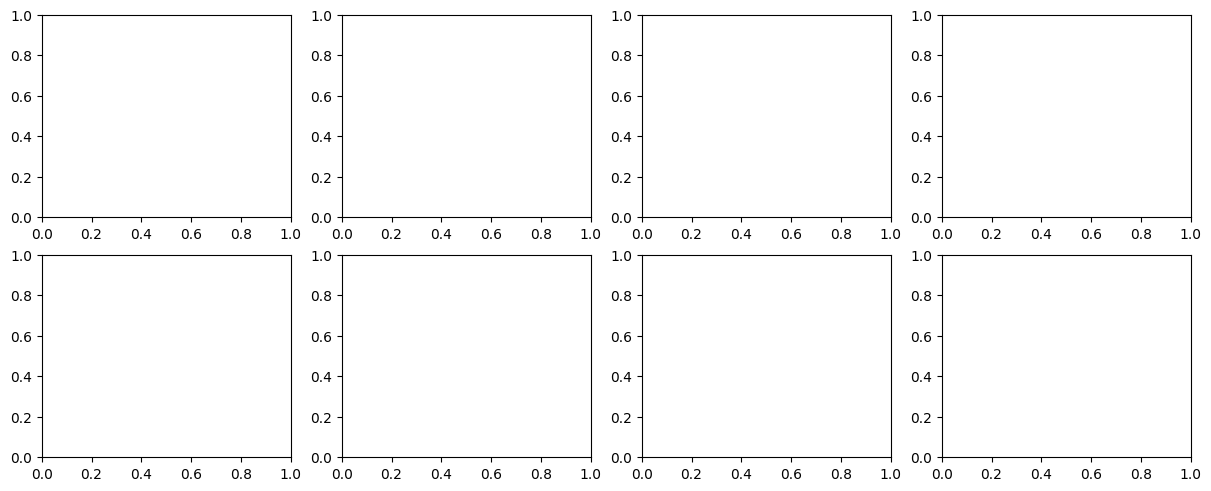

In [91]:
import matplotlib.pyplot as plt

# Set up the subplots
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(12, 4*1.2), constrained_layout=True)
ax = axarr.flatten()  # Flatten to make indexing easier
palette = plt.get_cmap('tab20')

# Plot observed salinity for May 2024
ax[1].plot(obs.time.sel(time=slice('04-01-2024', '09-01-2024')),
           obs['Salinity'].sel(depth=slice(2,5)).mean('depth').sel(HV=[1,3,4,5,6,7,8,9,10,12]).sel(time=slice('04-01-2024', '09-01-2024')).mean('HV'),
           label='May', color=palette(2))

ax[0].plot(s_values_combined.time, s_values_combined.sel(location=[1,3,4,5,6,7,8,9,10,12]).mean('location'),
           label='May', color=palette(1))

# Plot observed salinity for May 2024
ax[3].plot(obs.time.sel(time=slice('04-01-2024', '09-01-2024')),
           obs['Temperature'].sel(depth=slice(2,5)).mean('depth').sel(HV=[1,3,4,5,6,7,8,9,10,12]).sel(time=slice('04-01-2024', '09-01-2024')).mean('HV'),
           label='May', color=palette(2))
ax[3].set_ylim(4.5,12.5)

ax[2].plot(s_values_combined.time, t_values_combined.sel(location=[1,3,4,5,6,7,8,9,10,12]).mean('location'),
           label='May', color=palette(1))
ax[2].set_ylim(4.5,12.5)
ax[5].plot(obs.time.sel(time=slice('04-01-2024', '09-01-2024')),
           obs['Salinity'].sel(depth=slice(2,5)).mean('depth').sel(HV=[1]).sel(time=slice('04-01-2024', '09-01-2024')).mean('HV'),
           label='May', color=palette(2))

ax[4].plot(s_values_combined.time, s_values_combined.sel(location=[1]).mean('location'),
           label='May', color=palette(1))

# Plot observed salinity for May 2024
ax[7].plot(obs.time.sel(time=slice('04-01-2024', '09-01-2024')),
           obs['Temperature'].sel(depth=slice(2,5)).mean('depth').sel(HV=[1]).sel(time=slice('04-01-2024', '09-01-2024')).mean('HV'),
           label='May', color=palette(2))
ax[7].set_ylim(4.5,12.5)
ax[6].plot(s_values_combined.time, t_values_combined.sel(location=[1]).mean('location'),
           label='May', color=palette(1))
ax[6].set_ylim(4.5,12.5)
# Rotate x-axis labels for all subplots
for a in ax:
    a.tick_params(axis='x', rotation=45)  # Adjust rotation angle as needed
    
    
ax[0].set_title('salinity for all stations,\n 5 m depth MODEL')
ax[1].set_title('salinity for all stations,\n 5 m depth OBS')
ax[2].set_title('temperature for all stations,\n 5 m depth MODEL')
ax[3].set_title('temperate for all stations,\n 5 m depth OBS')
ax[4].set_title('salinity for station 1,\n 5 m depth MODEL')
ax[5].set_title('salinity for station 1,\n 5 m depth OBS')
ax[6].set_title('temperature for station 1,\n 5 m depth MODEL')
ax[7].set_title('temperate for station 1,\n 5 m depth OBS')
plt.show()



## Chlorophyll and Oxygen

In [ ]:
roms_output_bgc = ROMSOutput(
    grid=grid,
    path=[
        "/home/x-uheede/S/Iceland2_MARBL_2024_60m/Iceland2_MARBL_2024_bgc.20240[1-9]????????.nc",
    ],
    use_dask=True,
)

roms_output_temp = ROMSOutput(
    grid=grid,
    path=[
        "/home/x-uheede/S/Iceland2_MARBL_2024_60m/Iceland2_MARBL_2024_his.20240[1-9]????????.nc",
    ],
    use_dask=True,
)


In [ ]:
var_names=["spChl","diatChl","diazChl",'O2']

In [ ]:
bgc = roms_output_bgc.regrid(depth_levels=target_depth_levels_bgc,var_names=var_names)
temp= roms_output_temp.regrid(depth_levels=target_depth_levels_bgc,var_names=["temp"])
temp = temp.sel(time=bgc.time)

In [ ]:
bgc["spChl"].thin({'time': thinner_bgc}).load()
bgc["diatChl"].thin({'time': thinner_bgc}).load()
bgc["diazChl"].thin({'time': thinner_bgc}).load()

Chl_total=bgc["spChl"].thin({'time': thinner_bgc})+bgc["diatChl"].thin({'time': thinner_bgc})+bgc["diazChl"].thin({'time': thinner_bgc})
O2=bgc["O2"].thin({'time': thinner_bgc}).load()
temp=temp.thin({'time': thinner_bgc}).load()

In [ ]:
o2_points = []
chl_points = []
temp_points = []
for lat, lon in locations:
    o2_sel = O2.sel(
        lat=lat,
        lon=lon,
        method="nearest"
    )
    o2_points.append(o2_sel)
    chl_sel = Chl_total.sel(
        lat=lat,
        lon=lon,
        method="nearest"
    )
    chl_points.append(chl_sel)

    temp_sel = temp.sel(
        lat=lat,
        lon=lon,
        method="nearest"
    )
    temp_points.append(temp_sel)
    
# Combine into a single DataArray with a "station" dimension
o2_points = xr.concat(o2_points, dim="station")
chl_points = xr.concat(chl_points, dim="station")
temp_points = xr.concat(temp_points, dim="station")


o2_mean = o2_points.mean(dim="station")
chl_mean = chl_points.mean(dim="station")
temp_mean = temp_points.mean(dim="station")

# Depth bins
o2_0_5   = o2_mean.sel(depth=slice(0, 5)).mean(dim="depth")
o2_5_15  = o2_mean.sel(depth=slice(5, 15)).mean(dim="depth")
o2_15_30 = o2_mean.sel(depth=slice(15, 30)).mean(dim="depth")

# Depth bins
chl_0_5   = chl_mean.sel(depth=slice(0, 5)).mean(dim="depth")
chl_5_15  = chl_mean.sel(depth=slice(5, 15)).mean(dim="depth")
chl_15_30 = chl_mean.sel(depth=slice(15, 30)).mean(dim="depth")






In [ ]:
import gsw
SALINITY = 34.0  # PSU
o2_sat = xr.apply_ufunc(
    gsw.O2sol_SP_pt,
    SALINITY,
    temp_mean
)

In [ ]:
o2_sat_pct = 100.0 * o2_mean / o2_sat["temp"]

sat_0_5   = o2_sat_pct.sel(depth=slice(0, 5)).mean(dim="depth")
sat_5_15  = o2_sat_pct.sel(depth=slice(5, 15)).mean(dim="depth")
sat_15_30 = o2_sat_pct.sel(depth=slice(15, 30)).mean(dim="depth")

In [ ]:
o2_sat

In [ ]:
o2_sat["temp"]

In [ ]:
plt.figure(figsize=(10, 5), dpi=150)

plt.plot(o2_0_5.time, o2_0_5, label="0–5 m")
plt.plot(o2_5_15.time, o2_5_15, label="5–15 m")
plt.plot(o2_15_30.time, o2_15_30, label="15–30 m")

plt.xlabel("Time")
plt.ylabel("O₂")
plt.title("Mean O₂ at Selected Locations")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10, 5), dpi=150)

plt.plot(sat_0_5.time, sat_0_5, label="0–5 m")
plt.plot(sat_5_15.time, sat_5_15, label="5–15 m")
plt.plot(sat_15_30.time, sat_15_30, label="15–30 m")

plt.axhline(100, color="k", linestyle="--", linewidth=0.8, alpha=0.6)

plt.xlabel("Time")
plt.ylabel("O₂ Saturation (%)")
plt.title("Mean O₂ Saturation at Selected Locations")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10, 5), dpi=150)

plt.plot(chl_0_5.time, chl_0_5, label="0–5 m")
plt.plot(chl_5_15.time, chl_5_15, label="5–15 m")
plt.plot(chl_15_30.time, chl_15_30, label="15–30 m")

plt.xlabel("Time")
plt.ylabel("Chlorophyll")
plt.title("Mean Chl at Selected Locations")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Time window
obs_sel = obs.sel(time=slice(months_string_begin, months_string_end))

# Average across stations
obs_mean = obs_sel.sel(HV=[1,3,5,7,9,10,12]).mean(dim="HV")

def depth_avg_timeseries(ds, var, zmin, zmax):
    return ds[var].sel(depth=slice(zmin, zmax)).mean(dim="depth")

fl_0_5   = depth_avg_timeseries(obs_mean, "Fluor", 0, 5)
fl_5_15  = depth_avg_timeseries(obs_mean, "Fluor", 5, 15)
fl_15_30 = depth_avg_timeseries(obs_mean, "Fluor", 15, 30)


o2_0_5_obs   = depth_avg_timeseries(obs_mean, "Oxygen", 0, 5)
o2_5_15_obs  = depth_avg_timeseries(obs_mean, "Oxygen", 5, 15)
o2_15_30_obs = depth_avg_timeseries(obs_mean, "Oxygen", 15, 30)

sat_0_5_obs  = depth_avg_timeseries(obs_mean, "Saturation", 0, 5)
sat_5_15_obs  = depth_avg_timeseries(obs_mean, "Saturation", 5, 15)
sat_15_30_obs = depth_avg_timeseries(obs_mean, "Saturation", 15, 30)


In [ ]:
fig, axs = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 9),
    sharex="col",
    constrained_layout=True
)

depth_labels = ["0–5 m", "5–15 m", "15–30 m"]

# ==================================================
# Fluorescence
# ==================================================
# Observed (left)
axs[0, 0].plot(fl_0_5.time, fl_0_5, label=depth_labels[0],linestyle='-', marker='o')
axs[0, 0].plot(fl_5_15.time, fl_5_15, label=depth_labels[1],linestyle='--', marker='s')
axs[0, 0].plot(fl_15_30.time, fl_15_30, label=depth_labels[2],linestyle='-.', marker='v')
axs[0, 0].set_title("Observed")
axs[0, 0].set_ylabel("Fluorescence/Chlorophyll")
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.3)

# Modeled (right)
axs[0, 1].plot(chl_0_5.time, chl_0_5,linestyle='-', marker='o')
axs[0, 1].plot(chl_5_15.time, chl_5_15,linestyle='--', marker='s')
axs[0, 1].plot(chl_15_30.time, chl_15_30,linestyle='-.', marker='v')
axs[0, 1].set_title("Modeled")
axs[0, 1].grid(alpha=0.3)

# ==================================================
# Oxygen
# ==================================================
# Observed
axs[1, 0].plot(o2_0_5_obs.time, o2_0_5_obs,linestyle='-', marker='o')
axs[1, 0].plot(o2_5_15_obs.time, o2_5_15_obs,linestyle='--', marker='s')
axs[1, 0].plot(o2_15_30_obs.time, o2_15_30_obs,linestyle='-.', marker='v')
axs[1, 0].set_ylabel("Oxygen")
axs[1, 0].grid(alpha=0.3)

# Modeled
axs[1, 1].plot(o2_0_5.time, o2_0_5*0.032,linestyle='-', marker='o')
axs[1, 1].plot(o2_5_15.time, o2_5_15*0.032,linestyle='--', marker='s')
axs[1, 1].plot(o2_15_30.time, o2_15_30*0.032,linestyle='-.', marker='v')
axs[1, 1].grid(alpha=0.3)

# ==================================================
# Oxygen saturation
# ==================================================
# Observed
axs[2, 0].plot(sat_0_5_obs.time, sat_0_5_obs,linestyle='-', marker='o')
axs[2, 0].plot(sat_5_15_obs.time, sat_5_15_obs,linestyle='--', marker='s')
axs[2, 0].plot(sat_15_30_obs.time, sat_15_30_obs,linestyle='-.', marker='v')
axs[2, 0].axhline(100, color="k", linestyle="--", linewidth=0.8)
axs[2, 0].set_ylabel("O₂ Saturation (%)")
axs[2, 0].set_xlabel("Time")
axs[2, 0].grid(alpha=0.3)

# Modeled
axs[2, 1].plot(sat_0_5.time, sat_0_5,linestyle='-', marker='o')
axs[2, 1].plot(sat_5_15.time, sat_5_15,linestyle='--', marker='s')
axs[2, 1].plot(sat_15_30.time, sat_15_30,linestyle='-.', marker='v')
axs[2, 1].axhline(100, color="k", linestyle="--", linewidth=0.8)
axs[2, 1].set_xlabel("Time")
axs[2, 1].grid(alpha=0.3)

for ax in axs.flat:
    ax.tick_params(axis="x", rotation=45)

plt.show()


In [ ]:
fig, axs = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 7),
    sharex="col",
    constrained_layout=True
)

depth_labels = ["0–5 m", "5–15 m", "15–30 m"]

# ==================================================
# Oxygen
# ==================================================
# Observed (left)
axs[0, 0].plot(o2_0_5_obs.time, o2_0_5_obs, linestyle='-', marker='o', label=depth_labels[0])
axs[0, 0].plot(o2_5_15_obs.time, o2_5_15_obs, linestyle='--', marker='s', label=depth_labels[1])
axs[0, 0].plot(o2_15_30_obs.time, o2_15_30_obs, linestyle='-.', marker='v', label=depth_labels[2])
axs[0, 0].set_title("Observed")
axs[0, 0].set_ylabel("Oxygen")
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.3)

# Modeled (right)
axs[0, 1].plot(o2_0_5.time, o2_0_5 * 0.032, linestyle='-', marker='o')
axs[0, 1].plot(o2_5_15.time, o2_5_15 * 0.032, linestyle='--', marker='s')
axs[0, 1].plot(o2_15_30.time, o2_15_30 * 0.032, linestyle='-.', marker='v')
axs[0, 1].set_title("Modeled")
axs[0, 1].grid(alpha=0.3)

# ==================================================
# Oxygen saturation
# ==================================================
# Observed
axs[1, 0].plot(sat_0_5_obs.time, sat_0_5_obs, linestyle='-', marker='o')
axs[1, 0].plot(sat_5_15_obs.time, sat_5_15_obs, linestyle='--', marker='s')
axs[1, 0].plot(sat_15_30_obs.time, sat_15_30_obs, linestyle='-.', marker='v')
axs[1, 0].axhline(100, color="k", linestyle="--", linewidth=0.8)
axs[1, 0].set_ylabel("O₂ Saturation (%)")
axs[1, 0].set_xlabel("Time")
axs[1, 0].grid(alpha=0.3)

# Modeled
axs[1, 1].plot(sat_0_5.time, sat_0_5, linestyle='-', marker='o')
axs[1, 1].plot(sat_5_15.time, sat_5_15, linestyle='--', marker='s')
axs[1, 1].plot(sat_15_30.time, sat_15_30, linestyle='-.', marker='v')
axs[1, 1].axhline(100, color="k", linestyle="--", linewidth=0.8)
axs[1, 1].set_xlabel("Time")
axs[1, 1].grid(alpha=0.3)

for ax in axs.flat:
    ax.tick_params(axis="x", rotation=45)

plt.show()